In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    #'Native_novm': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/native_novm/summary_final.csv',
    'Native_default': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/native_default/summary_final.csv',
    'Native_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/native_interleave/summary_final.csv',
    'SME_default': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/sme_default/summary_final.csv',
    'SME_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/sme_interleave/summary_final.csv',
    #'SME_optimized': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/sme_optimized_autonumabalanceonhoston/summary_final.csv',
    'SEV_default': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/sev_default/summary_final.csv',
    'SEV_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/clean/sev_interleave/summary_final.csv', 
}

matrix_path = '../../matrices/spmv_synthetic/'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    if not os.path.exists(path): 
        print(f"Warning: File for {label} not found at {path}. Skipping.")
        return None
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])

group_cols = ['Mode', 'Cores', 'MB', 'Randomness', 'NUMA']
metrics = ['Gflops', 'Runtime', 'Insn', 'Cycl', 'RefCycl', 'Cache_Miss', 'Stalls', 'PgFault']

df = df_raw.groupby(group_cols)[metrics].mean().reset_index()

/tmp/ipykernel_208939/1065679862.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(['Randomness', 'Config', 'Affinity'], group_keys=False).apply(calc_rel_overhead)
/tmp/ipykernel_208939/1065679862.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['Randomness', 'Config', 'Affinity'], group_keys=False).apply(calc_rel_overhead)


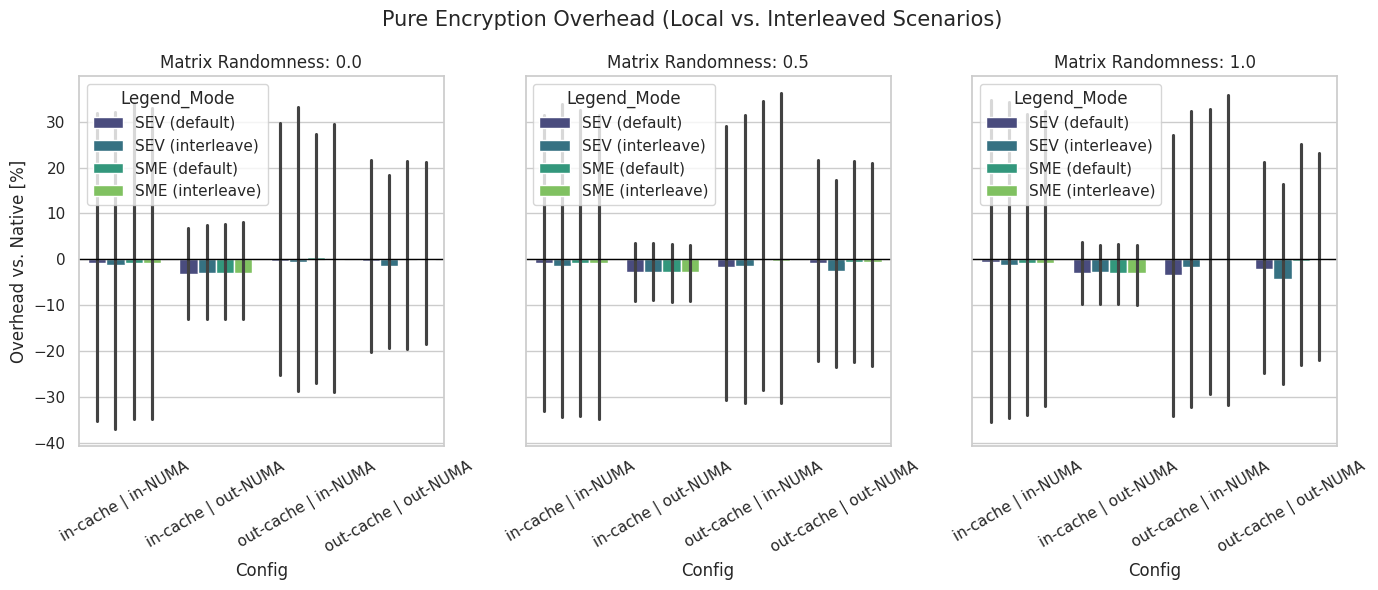

In [9]:
# --- 1. Daten vorbereiten (Splitting Mode & Affinity) ---
df[['BaseMode', 'Affinity']] = df['Mode'].str.split('_', expand=True)

# --- 2. Berechnung des Overheads relativ zur jeweiligen Native-Baseline ---
# Wir gruppieren nach Randomness, Config und Affinity, um den Native-Wert als Teiler zu finden
def calc_rel_overhead(group):
    native_val = group[group['BaseMode'] == 'Native']['Gflops'].mean()
    group['Rel_Deviation'] = (group['Gflops'] / native_val - 1.0) * 100.0
    return group

df = df.groupby(['Randomness', 'Config', 'Affinity'], group_keys=False).apply(calc_rel_overhead)

# Nur SME und SEV behalten (Native wäre jetzt 0%)
plot_df = df[df['BaseMode'] != 'Native'].copy()

# Wir kombinieren BaseMode und Affinity für die Legende (z.B. "SEV (interleave)")
plot_df['Legend_Mode'] = plot_df['BaseMode'] + " (" + plot_df['Affinity'] + ")"

# --- 3. Plotting ---
randomness_order = sorted(plot_df['Randomness'].unique())
fig, axes = plt.subplots(1, len(randomness_order), figsize=(14, 6), sharey=True)
axes = np.atleast_1d(axes)

for i, rnd in enumerate(randomness_order):
    ax = axes[i]
    sns.barplot(
        data=plot_df[plot_df['Randomness'] == rnd],
        x='Config',
        y='Rel_Deviation',
        hue='Legend_Mode',
        palette='viridis',
        ax=ax,
        order=config_order
    )
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Matrix Randomness: {rnd}')
    ax.set_ylabel('Overhead vs. Native [%]' if i == 0 else '')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Pure Encryption Overhead (Local vs. Interleaved Scenarios)', fontsize=15)
plt.tight_layout()
plt.show()

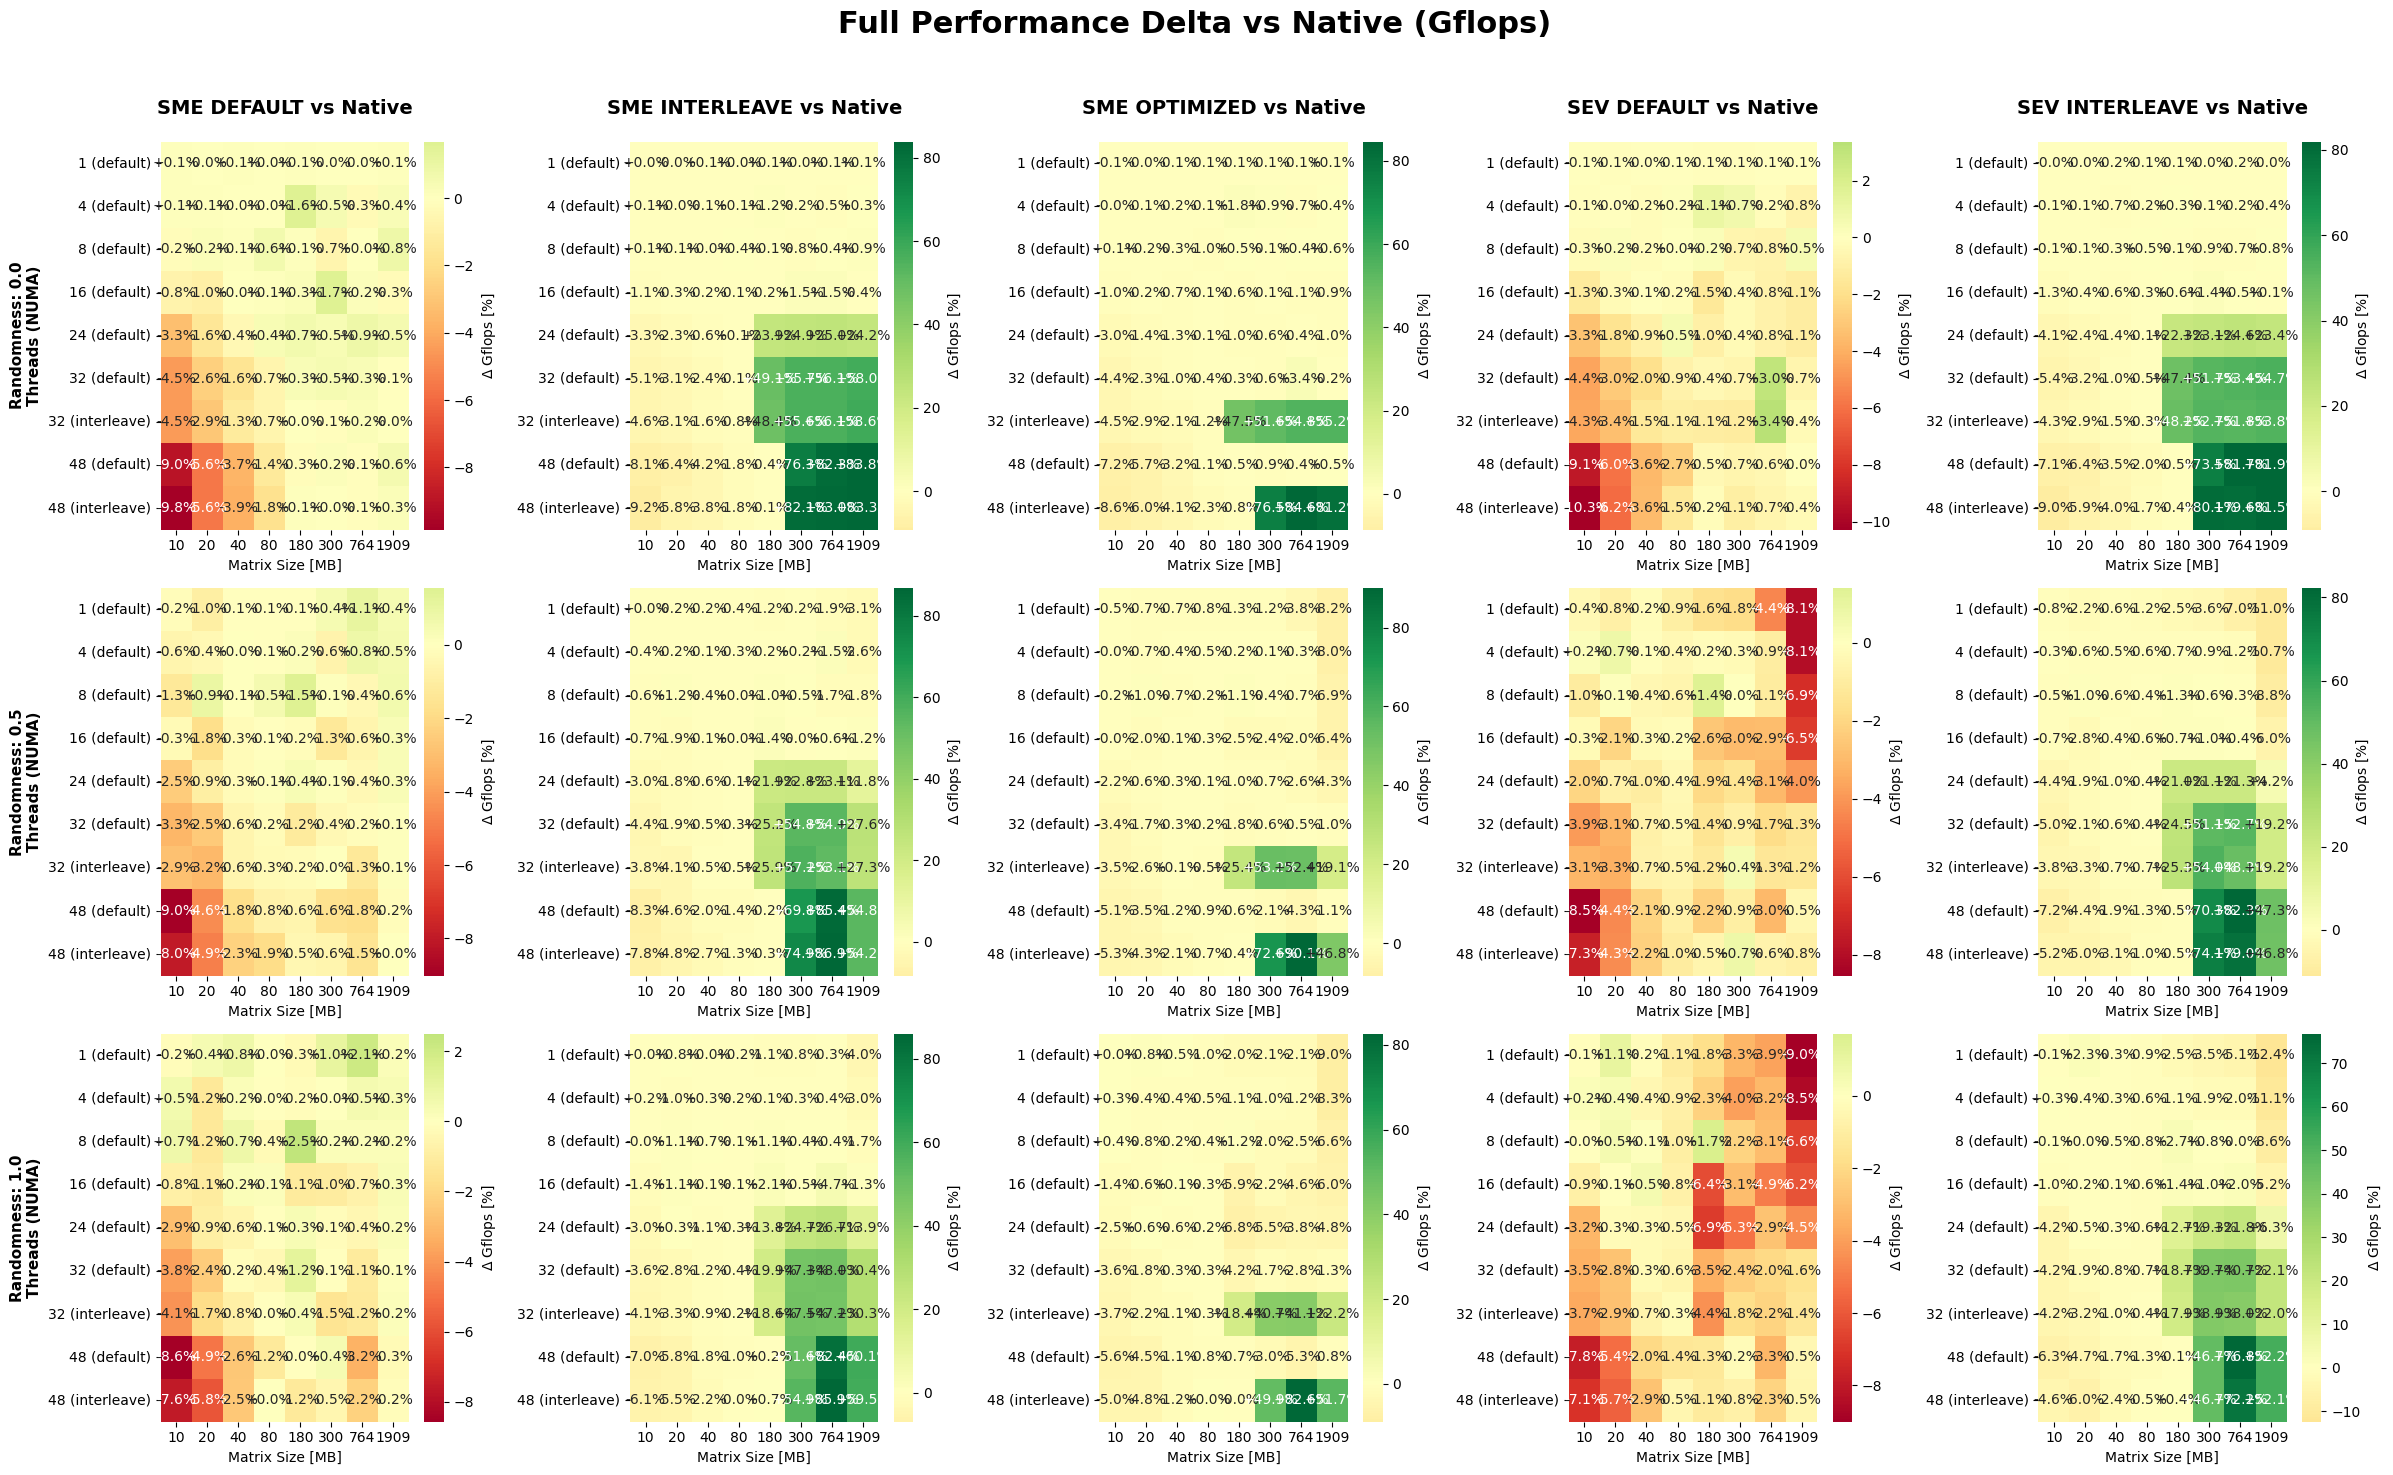

In [4]:
heat_pivot = df.pivot_table(
    index=['Cores', 'MB', 'Randomness', 'NUMA'], 
    columns='Mode', 
    values='Gflops'
).reset_index()

non_native_modes = ['SME_default', 'SME_interleave', 'SME_optimized', 'SEV_default', 'SEV_interleave']

for mode in non_native_modes:
    col_name = f'{mode}_vs_Nat_%'
    heat_pivot[col_name] = (heat_pivot[mode] / heat_pivot['Native'] - 1) * 100

heat_pivot = heat_pivot.sort_values(by=['Cores', 'NUMA'])
heat_pivot['Threads_Config'] = heat_pivot['Cores'].astype(str) + " (" + heat_pivot['NUMA'].astype(str) + ")"
config_order = heat_pivot['Threads_Config'].unique()
heat_pivot['Threads_Config'] = pd.Categorical(heat_pivot['Threads_Config'], categories=config_order, ordered=True)

modes_to_plot = [f'{m}_vs_Nat_%' for m in non_native_modes]
mode_titles = [m.replace('_', ' ').upper() + " vs Native" for m in non_native_modes]
unique_randomness = sorted(heat_pivot['Randomness'].unique())

fig, axes = plt.subplots(len(unique_randomness), 5, figsize=(24, 5 * len(unique_randomness)))
axes = np.atleast_2d(axes)

for i, rnd in enumerate(unique_randomness):
    row_data = heat_pivot[heat_pivot['Randomness'] == rnd]
    
    for j, (m_col, title) in enumerate(zip(modes_to_plot, mode_titles)):
        ax = axes[i, j]
        
        if row_data.empty or m_col not in row_data.columns:
            ax.set_visible(False)
            continue
            
        plot_data = row_data.pivot_table(
            index='Threads_Config', 
            columns='MB', 
            values=m_col, 
            sort=False,
            observed=False
        )
        
        sns.heatmap(
            plot_data, 
            ax=ax, 
            cmap='RdYlGn', 
            center=0, 
            annot=True, 
            fmt='+.1f', 
            cbar_kws={'label': '$\Delta$ Gflops [%]'}
        )
        
        # Add percent signs to annotations
        for text in ax.texts:
            t_val = text.get_text()
            if t_val and t_val != 'nan':
                text.set_text(f"{t_val}%")
        
        if i == 0:
            ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        
        if j == 0:
            ax.set_ylabel(f"Randomness: {rnd}\nThreads (NUMA)", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("Matrix Size [MB]")

plt.suptitle("Full Performance Delta vs Native (Gflops)", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

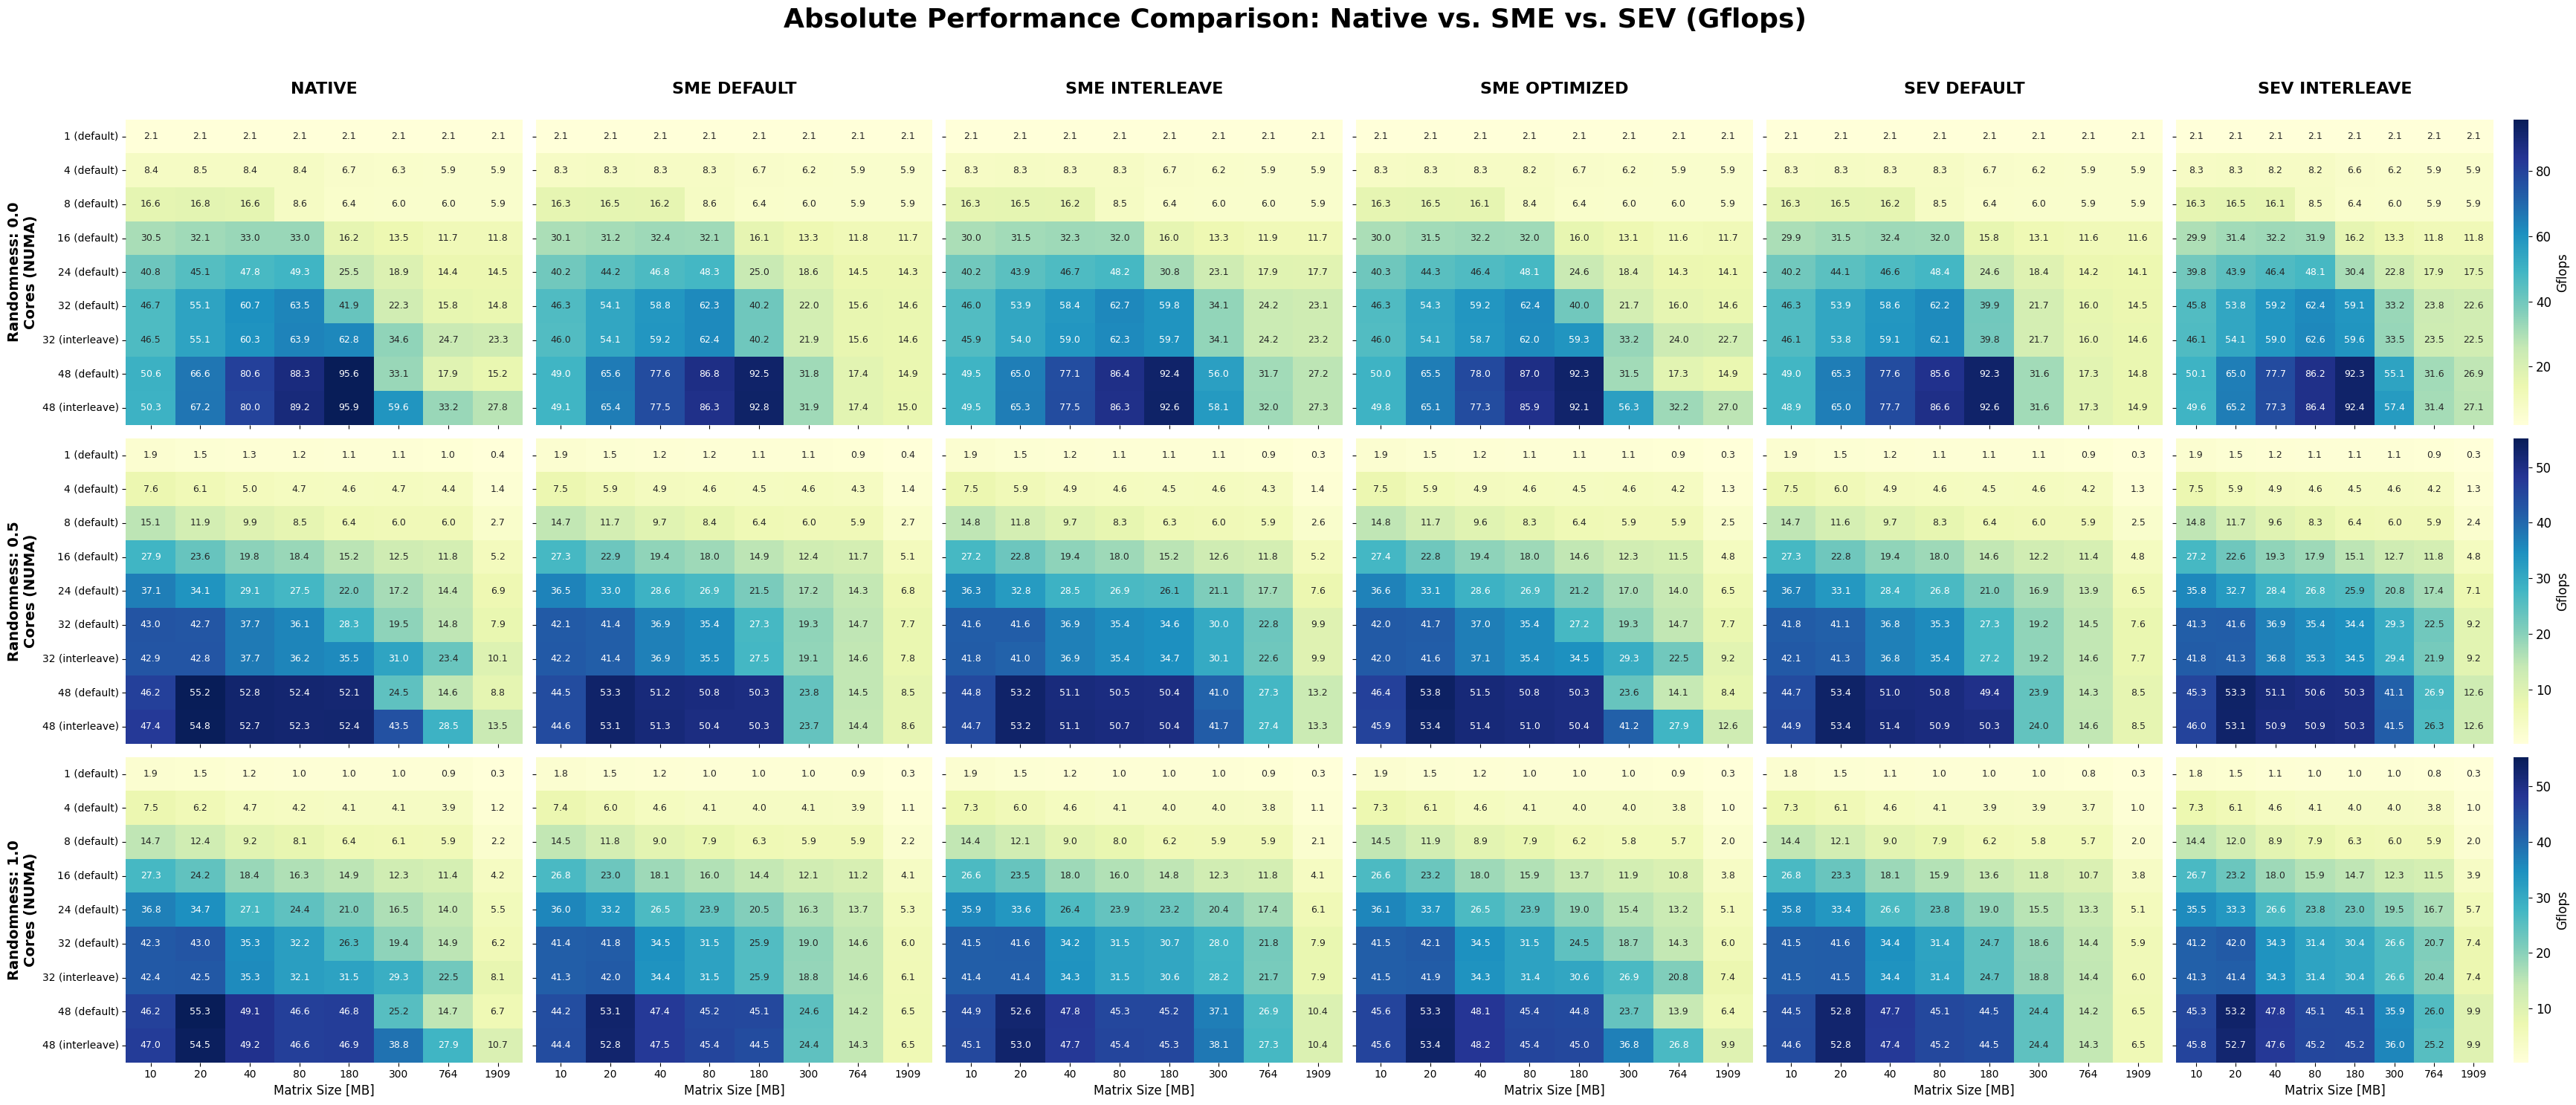

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Deine Liste bleibt
all_modes = ['Native', 'SME_default', 'SME_interleave', 'SME_optimized', 'SEV_default', 'SEV_interleave']

# Wir erhöhen die Breite massiv (auf 35 Zoll), damit 6 Spalten Platz haben
fig, axes = plt.subplots(len(unique_randomness), len(all_modes), 
                         figsize=(35, 5 * len(unique_randomness)), 
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

# Globales Schrift-Tuning
plt.rcParams.update({'font.size': 12})

for i, rnd in enumerate(unique_randomness):
    row_data = heat_pivot[heat_pivot['Randomness'] == rnd]
    
    # Ermittle Min/Max für die gesamte Zeile, damit die Farben vergleichbar sind
    # Das ist wichtig, um den Performance-Abfall von SEV visuell sofort zu sehen!
    v_min = row_data[all_modes].min().min()
    v_max = row_data[all_modes].max().max()

    for j, mode_col in enumerate(all_modes):
        ax = axes[i, j]
        
        if row_data.empty or mode_col not in row_data.columns:
            ax.set_visible(False)
            continue
            
        plot_data = row_data.pivot_table(
            index='Threads_Config', 
            columns='MB', 
            values=mode_col, 
            sort=False,
            observed=False
        )
        
        # Die eigentliche Heatmap
        sns.heatmap(
            plot_data, 
            ax=ax, 
            cmap='YlGnBu', 
            annot=True, 
            annot_kws={"size": 9}, # Kleiner, damit die Zahlen in die Boxen passen
            fmt='.1f',             # EINE Nachkommastelle spart massiv Platz
            vmin=v_min, vmax=v_max, # Einheitliche Skala pro Zeile!
            cbar=(j == len(all_modes)-1), # Colorbar nur ganz rechts
            cbar_kws={'label': 'Gflops'} if j == len(all_modes)-1 else None
        )
        
        # Titel nur in der ersten Zeile
        if i == 0:
            title_clean = mode_col.replace('_', ' ').upper()
            ax.set_title(title_clean, fontsize=16, fontweight='bold', pad=25)
        
        # Y-Label nur in der ersten Spalte
        if j == 0:
            ax.set_ylabel(f"Randomness: {rnd}\nCores (NUMA)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        # X-Label nur in der letzten Zeile
        if i == len(unique_randomness) - 1:
            ax.set_xlabel("Matrix Size [MB]", fontsize=12)
        else:
            ax.set_xlabel("")

plt.suptitle("Absolute Performance Comparison: Native vs. SME vs. SEV (Gflops)", 
             fontsize=26, fontweight='bold', y=0.99)

# Tight_layout mit Platz für die Überschrift
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()